# Regressão Linear From Scratch

## Objetivo

Este notebook tem como objetivo analisar um conjunto de dados de marketing e construir, do zero, um modelo de regressão linear para estimar `sales` a partir dos investimentos em `youtube`, `facebook` e `newspaper`.

In [1]:
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

In [2]:
warnings.filterwarnings("ignore")

sns.set_theme(
    style="ticks",
    font_scale=1.05,
    rc={"figure.figsize": (14, 6)},
    palette="deep",
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## Ambiente

As bibliotecas abaixo são suficientes para todo o projeto. A proposta continua sendo "from scratch" no modelo, então `numpy` é usado para a álgebra da regressão e `pandas` para manipulação tabular.


In [3]:
print(f"{pd.__name__} version {pd.__version__}")
print(f"{np.__name__} version {np.__version__}")
print(f"{sns.__name__} version {sns.__version__}")

pandas version 3.0.2
numpy version 2.4.4
seaborn version 0.13.2


## Carga de Dados

O arquivo CSV é localizado por tentativa em alguns caminhos prováveis. Isso evita que o notebook dependa rigidamente do diretório em que o Jupyter foi iniciado.


In [4]:
def find_data_file(file_name: str = "Marketing_Data.csv") -> Path:
    candidates = [
        Path("data") / file_name,
        Path("Linear Regression") / "data" / file_name,
        Path.cwd() / "data" / file_name,
        Path.cwd() / "Linear Regression" / "data" / file_name,
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    raise FileNotFoundError(f"Arquivo de dados não encontrado entre os caminhos testados: {candidates}")

In [5]:
DATA_PATH = find_data_file()
marketing_df = pd.read_csv(DATA_PATH)

In [6]:
print(f"Arquivo carregado: {DATA_PATH}")
print(f"Dimensão do dataset: {marketing_df.shape}")

Arquivo carregado: C:\WorkspaceHub\SourceHub\data-scientist\Linear Regression\data\Marketing_Data.csv
Dimensão do dataset: (171, 4)


In [7]:
marketing_df.head()

,youtube,facebook,newspaper,sales
0,84.72,19.20,48.96,12.60
1,351.48,33.96,51.84,25.68
2,135.48,20.88,46.32,14.28
3,116.64,1.80,36.00,11.52
4,318.72,24.00,0.36,20.88


## Entendimento Inicial dos Dados

Antes de modelar, vale confirmar tipos, distribuição geral e possíveis valores ausentes.


In [8]:
marketing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   youtube    171 non-null    float64
 1   facebook   171 non-null    float64
 2   newspaper  171 non-null    float64
 3   sales      171 non-null    float64
dtypes: float64(4)
memory usage: 5.5 KB


In [9]:
display(marketing_df.describe())

,youtube,facebook,newspaper,sales
count,171.000000,171.000000,171.000000,171.000000
mean,178.021053,27.671579,35.240000,16.922807
std,102.449597,17.913532,24.902918,6.314608
min,0.840000,0.000000,0.360000,1.920000
25%,91.080000,11.700000,13.740000,12.540000
50%,179.760000,26.760000,31.080000,15.480000
75%,262.980000,43.680000,50.880000,20.820000
max,355.680000,59.520000,121.080000,32.400000


In [10]:
display(marketing_df.isna().sum().rename("missing_values").to_frame())

,missing_values
youtube,0
facebook,0
newspaper,0
sales,0


## Variáveis do Projeto

- `sales`: variável alvo
- `youtube`, `facebook`, `newspaper`: variáveis explicativas


In [11]:
target_column = "sales"
feature_columns = [column for column in marketing_df.columns if column != target_column]
color_palette = {"youtube": "#1f77b4", "facebook": "#ff7f0e", "newspaper": "#2ca02c"}
axis_labels = {
    "youtube": "Investimento em YouTube",
    "facebook": "Investimento em Facebook",
    "newspaper": "Investimento em Newspaper",
    "sales": "Vendas",
}

print("Features:", feature_columns)

Features: ['youtube', 'facebook', 'newspaper']


## Correlação de Pearson Implementada Manualmente

Esta etapa calcula a correlação de Pearson sem usar a implementação pronta do `pandas`. O objetivo é mostrar a lógica matemática por trás da medida de associação linear.


In [12]:
def pearson_correlation_manual(df: pd.DataFrame, target_variable: str) -> dict[str, float]:
    if target_variable not in df.columns:
        raise ValueError(f"A variável alvo '{target_variable}' não foi encontrada no DataFrame.")

    if not pd.api.types.is_numeric_dtype(df[target_variable]):
        raise ValueError(f"A variável alvo '{target_variable}' deve ser numérica.")

    target_data_raw = df[target_variable].tolist()
    correlations: dict[str, float] = {}

    for column in df.columns:
        if column == target_variable or not pd.api.types.is_numeric_dtype(df[column]):
            continue

        current_data_raw = df[column].tolist()
        valid_x_data = []
        valid_y_data = []

        for x_value, y_value in zip(current_data_raw, target_data_raw):
            if not (math.isnan(x_value) or math.isnan(y_value)):
                valid_x_data.append(x_value)
                valid_y_data.append(y_value)

        valid_data_size = len(valid_x_data)
        if valid_data_size < 2:
            continue

        mean_x = sum(valid_x_data) / valid_data_size
        mean_y = sum(valid_y_data) / valid_data_size

        sum_squared_deviations_x = 0.0
        sum_squared_deviations_y = 0.0
        sum_product_covariance = 0.0

        for x_data_point, y_data_point in zip(valid_x_data, valid_y_data):
            difference_from_mean_x = x_data_point - mean_x
            difference_from_mean_y = y_data_point - mean_y

            sum_squared_deviations_x += difference_from_mean_x ** 2
            sum_squared_deviations_y += difference_from_mean_y ** 2
            sum_product_covariance += difference_from_mean_x * difference_from_mean_y

        denominator = math.sqrt(sum_squared_deviations_x * sum_squared_deviations_y)
        if denominator == 0:
            continue

        correlations[column] = sum_product_covariance / denominator

    return correlations

In [13]:
correlations = pearson_correlation_manual(marketing_df, target_column)
correlation_df = (
    pd.DataFrame.from_dict(correlations, orient="index", columns=["pearson_r"])
    .sort_values("pearson_r", ascending=False)
)
correlation_df["r_squared"] = correlation_df["pearson_r"] ** 2

In [14]:
def plot_horizontal_bar(
    data: dict[str, float],
    title: str,
    xlabel: str = "Valor",
    ylabel: str = "Variável",
) -> None:
    fig, ax = plt.subplots(figsize=(10, 4))
    labels = list(data.keys())
    values = list(data.values())
    bars = ax.barh(labels, values, color=[color_palette.get(label, "#4c72b0") for label in labels])
    ax.bar_label(bars, fmt="%.3f", padding=3)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.tight_layout()
    plt.show()

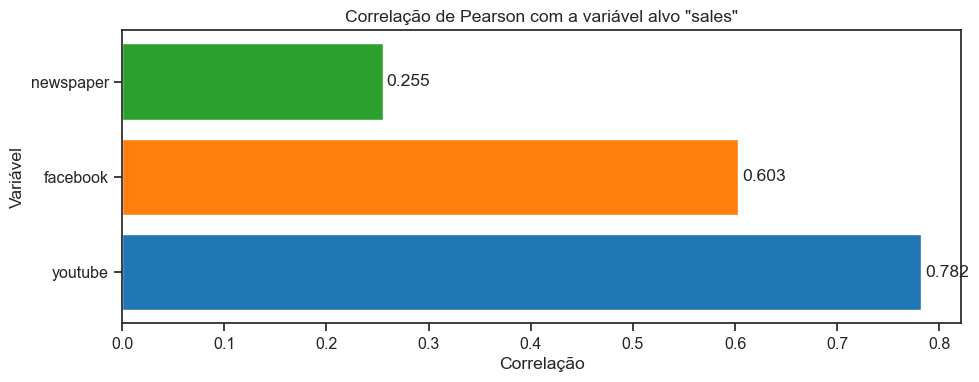

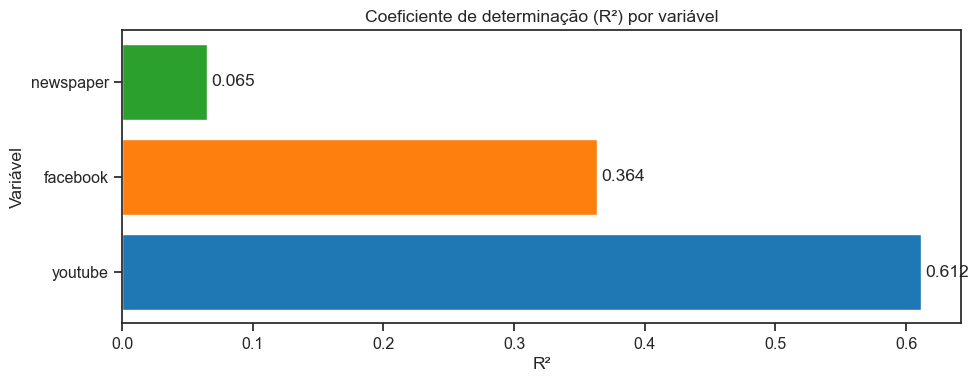

In [15]:
plot_horizontal_bar(
    correlations,
    'Correlação de Pearson com a variável alvo "sales"',
    xlabel="Correlação",
)

plot_horizontal_bar(
    correlation_df["r_squared"].to_dict(),
    'Coeficiente de determinação (R²) por variável',
    xlabel="R²",
)

In [16]:
display(correlation_df)

,pearson_r,r_squared
youtube,0.782030,0.611571
facebook,0.602918,0.363510
newspaper,0.254987,0.065018


## Distribuições e Relações Visuais

Os gráficos abaixo ajudam a verificar distribuição dos investimentos e relação visual entre cada canal e a variável alvo.


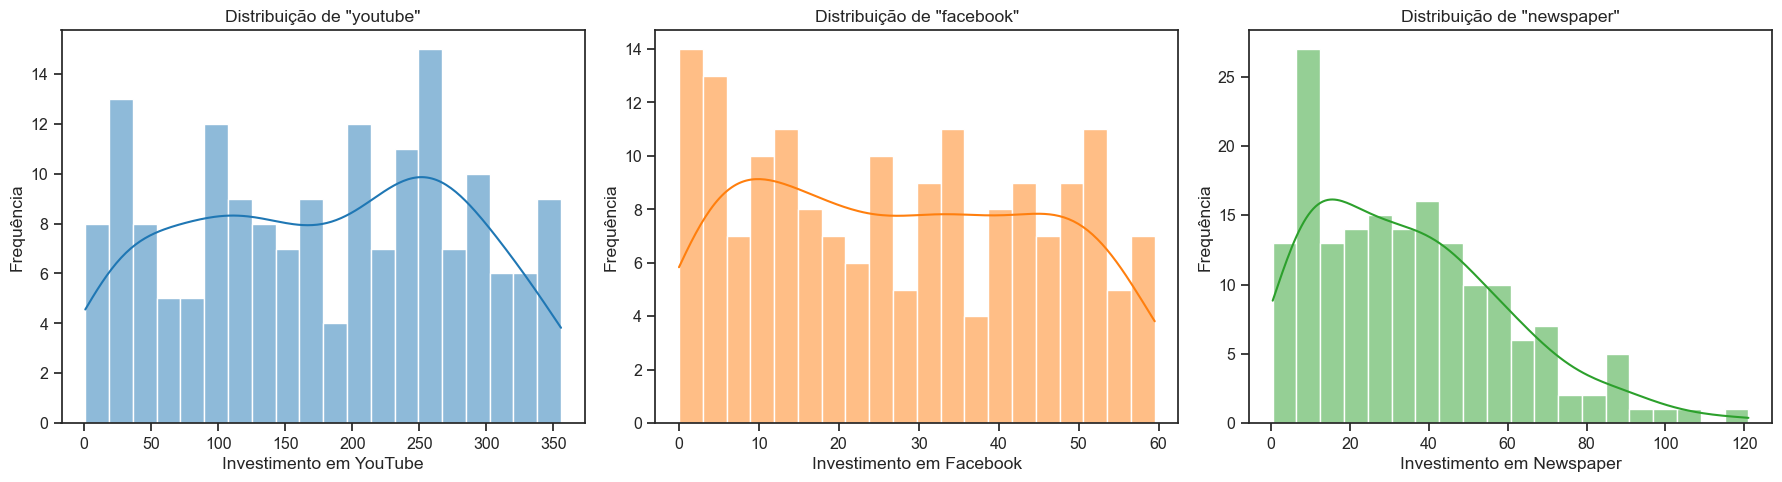

In [17]:
fig, axes = plt.subplots(1, len(feature_columns), figsize=(18, 5))

for ax, column in zip(axes, feature_columns):
    sns.histplot(marketing_df[column], bins=20, kde=True, color=color_palette[column], ax=ax)
    ax.set_title(f'Distribuição de "{column}"')
    ax.set_xlabel(axis_labels[column])
    ax.set_ylabel("Frequência")

plt.tight_layout()
plt.show()


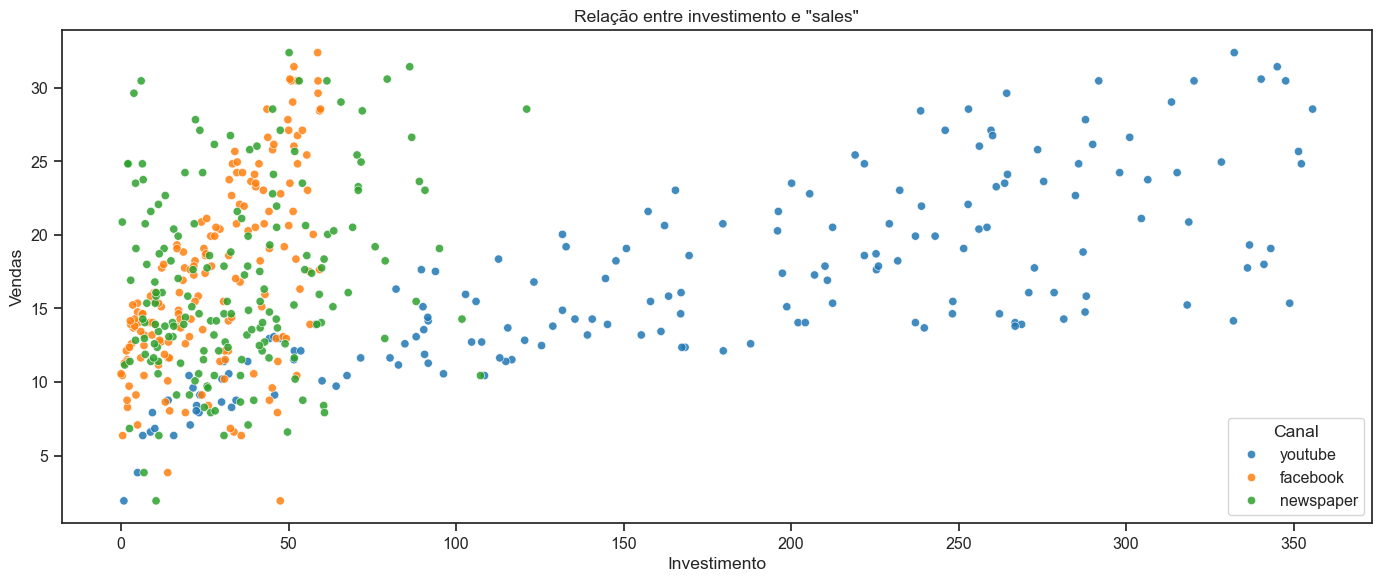

In [18]:
plot_df = marketing_df.melt(
    id_vars=target_column,
    value_vars=feature_columns,
    var_name="variable",
    value_name="investment",
)

sns.scatterplot(
    data=plot_df,
    x="investment",
    y=target_column,
    hue="variable",
    palette=color_palette,
    alpha=0.85,
)
plt.title('Relação entre investimento e "sales"')
plt.xlabel("Investimento")
plt.ylabel("Vendas")
plt.legend(loc="best", title="Canal")
plt.tight_layout()
plt.show()


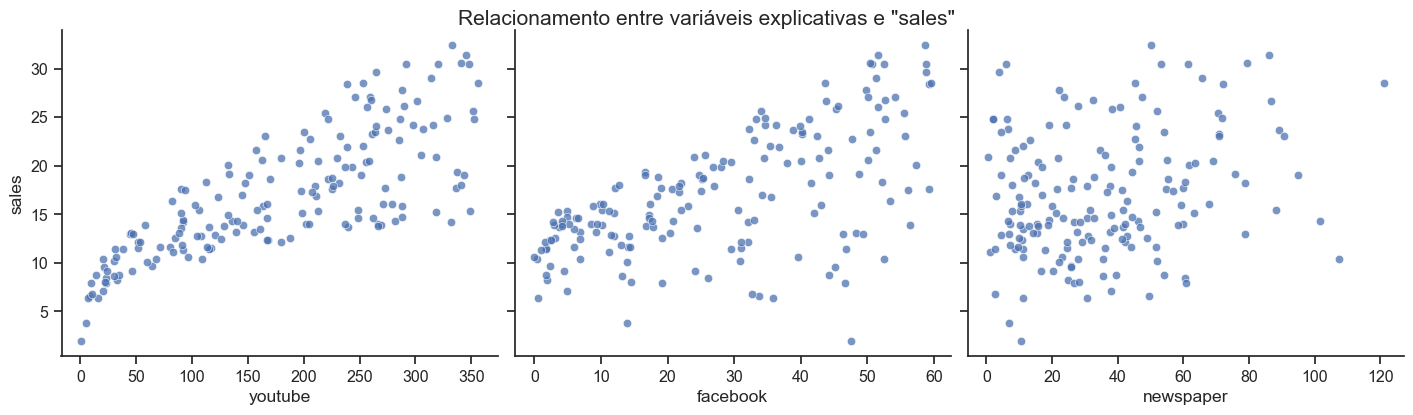

In [19]:
sns.pairplot(
    marketing_df,
    x_vars=feature_columns,
    y_vars=target_column,
    height=4,
    aspect=1.2,
    plot_kws={"alpha": 0.75},
)

plt.suptitle('Relacionamento entre variáveis explicativas e "sales"', y=1.02)
plt.show()


## Regressão Linear Múltipla From Scratch

Agora o projeto avança da análise exploratória para o modelo de fato. A implementação abaixo usa a equação normal:

`beta = (X^T X)^(-1) X^T y`

Para melhorar a estabilidade numérica, usamos a pseudo-inversa (`pinv`) no lugar da inversa clássica.


In [20]:
def train_test_split_manual(
    df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str,
    test_size: float = 0.2,
    random_seed: int = 42,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    if not 0 < test_size < 1:
        raise ValueError("test_size deve estar entre 0 e 1.")

    shuffled_indices = np.random.default_rng(random_seed).permutation(len(df))
    test_count = int(len(df) * test_size)
    test_indices = shuffled_indices[:test_count]
    train_indices = shuffled_indices[test_count:]

    X = df[feature_cols].to_numpy(dtype=float)
    y = df[target_col].to_numpy(dtype=float)

    return X[train_indices], X[test_indices], y[train_indices], y[test_indices]


def fit_linear_regression_normal_equation(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    X_with_bias = np.c_[np.ones(len(X)), X]
    beta = np.linalg.pinv(X_with_bias.T @ X_with_bias) @ X_with_bias.T @ y
    return beta


def predict_linear_regression(X: np.ndarray, beta: np.ndarray) -> np.ndarray:
    X_with_bias = np.c_[np.ones(len(X)), X]
    return X_with_bias @ beta


def mean_absolute_error_manual(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))


def root_mean_squared_error_manual(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def r2_score_manual(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    return 1 - (ss_res / ss_tot)

In [21]:
X_train, X_test, y_train, y_test = train_test_split_manual(
    marketing_df,
    feature_columns,
    target_column,
    test_size=0.2,
    random_seed=RANDOM_SEED,
)

beta = fit_linear_regression_normal_equation(X_train, y_train)
y_pred_train = predict_linear_regression(X_train, beta)
y_pred_test = predict_linear_regression(X_test, beta)

coefficients_df = pd.DataFrame(
    {
        "feature": ["intercept", *feature_columns],
        "coefficient": beta,
    }
)

In [22]:
display(coefficients_df)

,feature,coefficient
0,intercept,3.198480
1,youtube,0.045826
2,facebook,0.190530
3,newspaper,0.005345


## Avaliação do Modelo

As métricas abaixo mostram o desempenho em treino e teste. O principal foco é verificar se o modelo generaliza bem e se os coeficientes aprendidos fazem sentido frente às correlações observadas anteriormente.


In [23]:
metrics_df = pd.DataFrame(
    [
        {
            "dataset": "train",
            "mae": mean_absolute_error_manual(y_train, y_pred_train),
            "rmse": root_mean_squared_error_manual(y_train, y_pred_train),
            "r2": r2_score_manual(y_train, y_pred_train),
        },
        {
            "dataset": "test",
            "mae": mean_absolute_error_manual(y_test, y_pred_test),
            "rmse": root_mean_squared_error_manual(y_test, y_pred_test),
            "r2": r2_score_manual(y_test, y_pred_test),
        },
    ]
)

In [24]:
display(metrics_df)

,dataset,mae,rmse,r2
0,train,1.503183,2.013153,0.899295
1,test,1.505643,1.898450,0.902649


In [25]:
results_df = pd.DataFrame(
    {
        "actual_sales": y_test,
        "predicted_sales": y_pred_test,
        "residual": y_test - y_pred_test,
    }
).sort_values("actual_sales")

In [26]:
display(results_df.head(10))

,actual_sales,predicted_sales,residual
20,7.08,5.284409,1.795591
13,8.76,12.568428,-3.808428
10,8.76,5.325838,3.434162
7,11.28,7.677658,3.602342
11,11.40,10.569256,0.830744
28,11.52,9.079012,2.440988
14,11.64,9.788466,1.851534
4,12.12,11.889278,0.230722
21,12.12,11.898300,0.221700
19,12.48,10.474438,2.005562


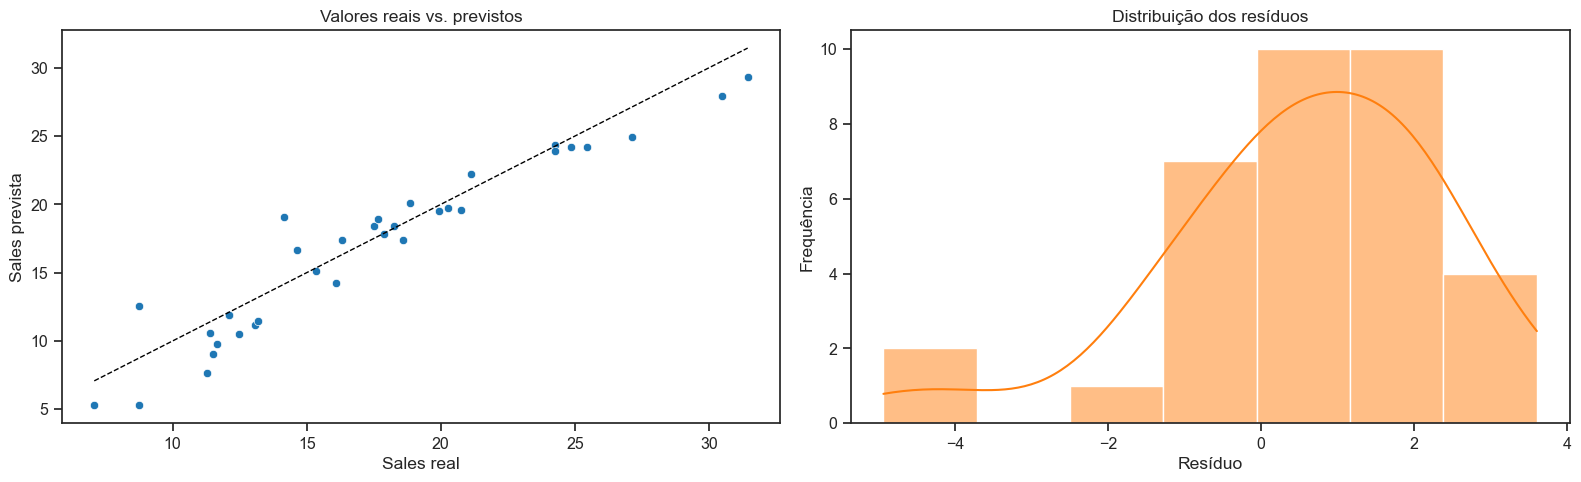

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.scatterplot(x=y_test, y=y_pred_test, ax=axes[0], color="#1f77b4")
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    color="black",
    linewidth=1,
)
axes[0].set_title("Valores reais vs. previstos")
axes[0].set_xlabel("Sales real")
axes[0].set_ylabel("Sales prevista")

sns.histplot(results_df["residual"], kde=True, ax=axes[1], color="#ff7f0e")
axes[1].set_title("Distribuição dos resíduos")
axes[1].set_xlabel("Resíduo")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()